✅ Librairies importées
X shape: (30000, 35), y shape: (30000,)
Taux de défaut: 22.12%
Train: 24000
Test: 6000

=== APRÈS SMOTE ===
Classe 0 (non défaut): 18691
Classe 1 (défaut): 18691

OPTIMISATION XGBOOST
⏳ GridSearch en cours (5-10 minutes)...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

✅ Temps écoulé: 322.64 secondes

✅ Meilleurs paramètres XGBoost:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
✅ Meilleur ROC-AUC (CV): 0.9278

OPTIMISATION RANDOM FOREST
⏳ GridSearch en cours (3-5 minutes)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

✅ Temps écoulé: 168.65 secondes

✅ Meilleurs paramètres Random Forest:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
✅ Meilleur ROC-AUC (CV): 0.8602

=== XGBoost Optimized ===
Matrice de confusion:
[[4268  405]
 [ 826  501]]
Recall: 0.3775
ROC-AUC: 0.7501

=== Random Forest Optimized ===
Matrice de confusion:
[[37

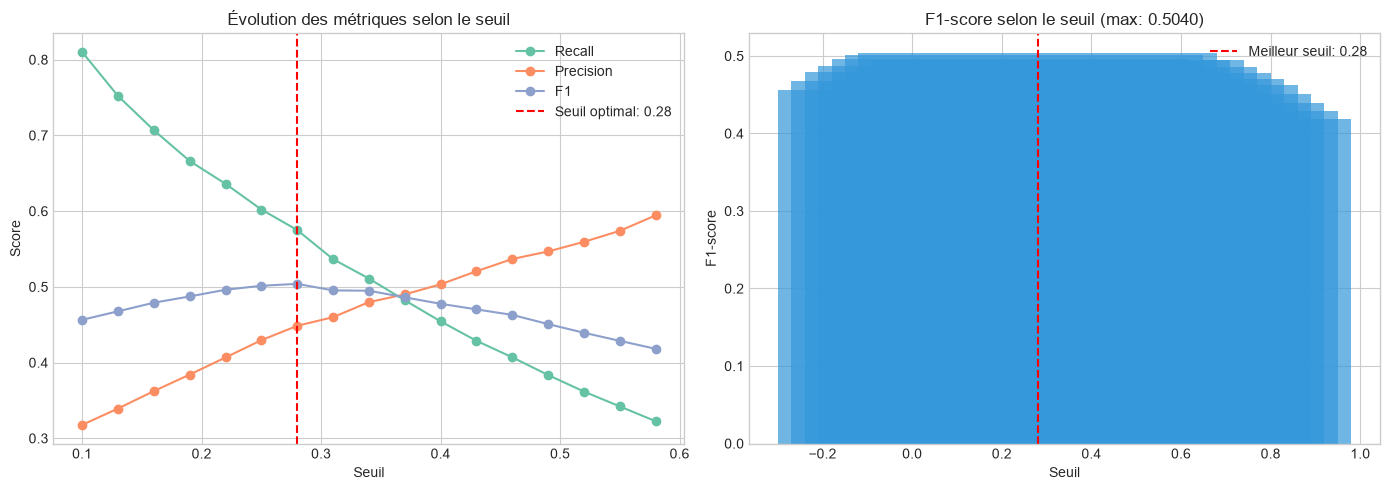


MODÈLE FINAL - XGBoost Optimized + Seuil Optimal
Seuil: 0.28
Accuracy: 0.7497
Precision: 0.4486
Recall: 0.5750
F1-score: 0.5040
ROC-AUC: 0.7501

Matrice de confusion:
[[3735  938]
 [ 564  763]]

✅ Modèle final sauvegardé !
   - Modèle: models/xgboost_final_optimized.pkl
   - Scaler: models/scaler_final.pkl
   - Seuil: models/best_threshold.txt
   - Features: models/feature_names_final.txt

COMPARAISON DES PERFORMANCES
                      Modèle  Accuracy  Precision  Recall  F1-score  ROC-AUC
0    XGBoost + SMOTE (avant)    0.8051     0.6197  0.3092    0.4126   0.7709
1  XGBoost Optimized + Seuil    0.7497     0.4486  0.5750    0.5040   0.7501


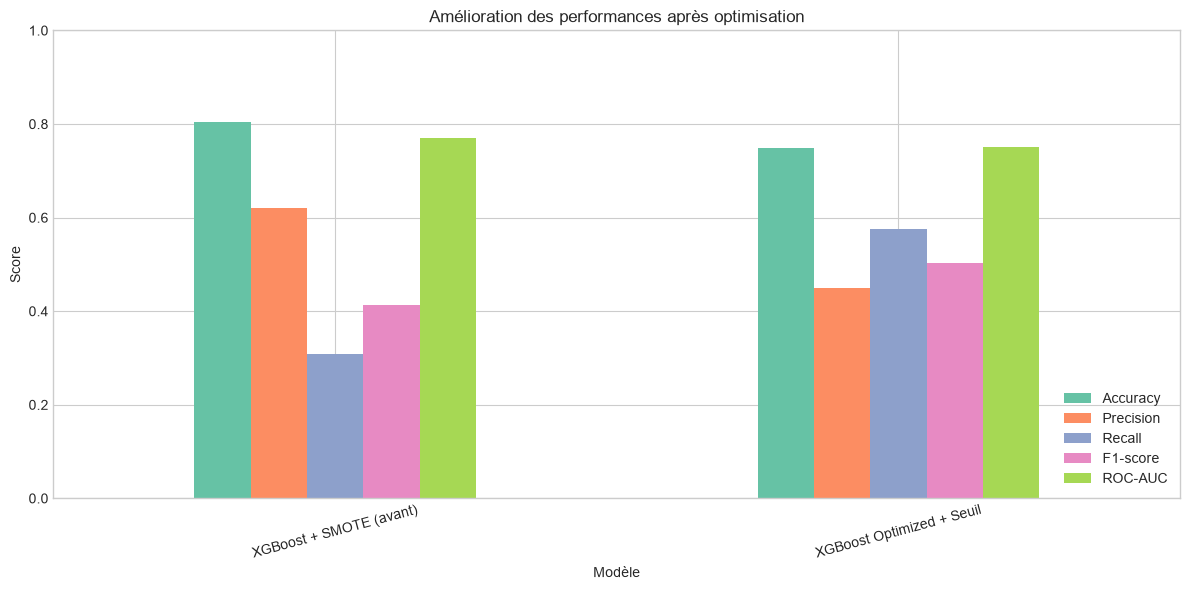


✅ Optimisation terminée !


In [1]:
# %% [markdown]
# # 07 - Optimization des performances
# ## Projet : AI Credit Risk Prediction Platform
# ## GridSearch + Ajustement du seuil

# %% [markdown]
# ### 1. Import des librairies

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTE
import joblib
import time

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Librairies importées")

# %% [markdown]
# ### 2. Chargement des données

# %%
X = pd.read_csv('../data/processed/X_features.csv')
y = pd.read_csv('../data/processed/y_target.csv').values.ravel()

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Taux de défaut: {y.mean()*100:.2f}%")

# %% [markdown]
# ### 3. Split des données

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}")
print(f"Test: {X_test.shape[0]}")

# %% [markdown]
# ### 4. SMOTE (pour l'entraînement)

# %%
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n=== APRÈS SMOTE ===")
print(f"Classe 0 (non défaut): {sum(y_train_smote==0)}")
print(f"Classe 1 (défaut): {sum(y_train_smote==1)}")

# %% [markdown]
# ### 5. OPTIMISATION XGBOOST

# %%
print("\n" + "="*60)
print("OPTIMISATION XGBOOST")
print("="*60)
print("⏳ GridSearch en cours (5-10 minutes)...")

start_time = time.time()

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_xgb = GridSearchCV(
    xgb, param_grid_xgb, 
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_smote, y_train_smote)

print(f"\n✅ Temps écoulé: {time.time() - start_time:.2f} secondes")
print(f"\n✅ Meilleurs paramètres XGBoost:")
print(grid_xgb.best_params_)
print(f"✅ Meilleur ROC-AUC (CV): {grid_xgb.best_score_:.4f}")

best_xgb = grid_xgb.best_estimator_

# %% [markdown]
# ### 6. OPTIMISATION RANDOM FOREST

# %%
print("\n" + "="*60)
print("OPTIMISATION RANDOM FOREST")
print("="*60)
print("⏳ GridSearch en cours (3-5 minutes)...")

start_time = time.time()

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_smote, y_train_smote)

print(f"\n✅ Temps écoulé: {time.time() - start_time:.2f} secondes")
print(f"\n✅ Meilleurs paramètres Random Forest:")
print(grid_rf.best_params_)
print(f"✅ Meilleur ROC-AUC (CV): {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_

# %% [markdown]
# ### 7. ÉVALUATION DES MODÈLES OPTIMISÉS

# %%
models = {
    'XGBoost Optimized': best_xgb,
    'Random Forest Optimized': best_rf
}

results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"=== {name} ===")
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    
    cm = confusion_matrix(y_test, y_pred)
    print(f"Matrice de confusion:\n{cm}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# %% [markdown]
# ### 8. AJUSTEMENT DU SEUIL DE DÉCISION

# %%
print("\n" + "="*60)
print("AJUSTEMENT DU SEUIL - XGBoost")
print("="*60)

# Récupérer les probabilités
y_proba = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Tester différents seuils
thresholds = np.arange(0.1, 0.6, 0.03)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    threshold_results.append({
        'Seuil': thresh,
        'Recall': recall_score(y_test, y_pred_thresh),
        'Precision': precision_score(y_test, y_pred_thresh),
        'F1': f1_score(y_test, y_pred_thresh)
    })

df_thresh = pd.DataFrame(threshold_results)

# Meilleur seuil selon F1
best_thresh = df_thresh.loc[df_thresh['F1'].idxmax(), 'Seuil']
best_f1 = df_thresh['F1'].max()

print(f"\n✅ Meilleur seuil: {best_thresh:.2f}")
print(f"✅ Meilleur F1-score: {best_f1:.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_thresh.plot(x='Seuil', y=['Recall', 'Precision', 'F1'], ax=axes[0], marker='o')
axes[0].set_title('Évolution des métriques selon le seuil')
axes[0].set_ylabel('Score')
axes[0].grid(True)
axes[0].axvline(best_thresh, color='red', linestyle='--', label=f'Seuil optimal: {best_thresh:.2f}')
axes[0].legend()

axes[1].bar(df_thresh['Seuil'], df_thresh['F1'], color='#3498db', alpha=0.7)
axes[1].axvline(best_thresh, color='red', linestyle='--', label=f'Meilleur seuil: {best_thresh:.2f}')
axes[1].set_title(f'F1-score selon le seuil (max: {best_f1:.4f})')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('F1-score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/threshold_optimization.png', dpi=150)
plt.show()

# %% [markdown]
# ### 9. MODÈLE FINAL AVEC SEUIL OPTIMAL

# %%
# Prédictions avec le seuil optimal
y_pred_optimal = (y_proba >= best_thresh).astype(int)

print("\n" + "="*60)
print("MODÈLE FINAL - XGBoost Optimized + Seuil Optimal")
print("="*60)

print(f"Seuil: {best_thresh:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_optimal):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Matrice de confusion
cm_final = confusion_matrix(y_test, y_pred_optimal)
print(f"\nMatrice de confusion:")
print(cm_final)

# %% [markdown]
# ### 10. SAUVEGARDE DU MODÈLE FINAL

# %%
# Sauvegarde du modèle, du scaler, du seuil et des features
joblib.dump(best_xgb, '../models/xgboost_final_optimized.pkl')
joblib.dump(scaler, '../models/scaler_final.pkl')

with open('../models/best_threshold.txt', 'w') as f:
    f.write(str(best_thresh))

feature_names = X.columns.tolist()
with open('../models/feature_names_final.txt', 'w') as f:
    for feat in feature_names:
        f.write(f"{feat}\n")

print("\n✅ Modèle final sauvegardé !")
print(f"   - Modèle: models/xgboost_final_optimized.pkl")
print(f"   - Scaler: models/scaler_final.pkl")
print(f"   - Seuil: models/best_threshold.txt")
print(f"   - Features: models/feature_names_final.txt")

# %% [markdown]
# ### 11. COMPARAISON FINALE

# %%
print("\n" + "="*60)
print("COMPARAISON DES PERFORMANCES")
print("="*60)

# Résultats avant optimisation (du notebook 05)
before = {
    'Modèle': 'XGBoost + SMOTE (avant)',
    'Accuracy': 0.8051,
    'Precision': 0.6197,
    'Recall': 0.3092,
    'F1-score': 0.4126,
    'ROC-AUC': 0.7709
}

# Résultats après optimisation
after = {
    'Modèle': 'XGBoost Optimized + Seuil',
    'Accuracy': accuracy_score(y_test, y_pred_optimal),
    'Precision': precision_score(y_test, y_pred_optimal),
    'Recall': recall_score(y_test, y_pred_optimal),
    'F1-score': f1_score(y_test, y_pred_optimal),
    'ROC-AUC': roc_auc_score(y_test, y_proba)
}

comparison = pd.DataFrame([before, after])
print(comparison.round(4))

# Sauvegarde
comparison.to_csv('../data/processed/performance_comparison.csv', index=False)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
comparison.plot(kind='bar', x='Modèle', ax=ax)
ax.set_title('Amélioration des performances après optimisation')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/performance_improvement.png', dpi=150)
plt.show()

print("\n✅ Optimisation terminée !")





MODÈLE RÉGULARISÉ - ANTI-OVERFITTING

=== PERFORMANCES MODÈLE RÉGULARISÉ ===
Accuracy: 0.7938
Precision: 0.5389
Recall: 0.4695
F1-score: 0.5018
ROC-AUC: 0.7634

Matrice de confusion:
[[4140  533]
 [ 704  623]]

AJUSTEMENT DU SEUIL - MODÈLE RÉGULARISÉ

✅ Meilleur seuil: 0.43
✅ Meilleur F1-score: 0.5182

MODÈLE RÉGULARISÉ + SEUIL OPTIMAL
Seuil: 0.43
Accuracy: 0.7700
Precision: 0.4828
Recall: 0.5592
F1-score: 0.5182
ROC-AUC: 0.7634

Matrice de confusion:
[[3878  795]
 [ 585  742]]

COMPARAISON FINALE - TOUS LES MODÈLES
                               Modèle  Accuracy  Precision  Recall  F1-score  \
0       XGBoost Optimized (seuil 0.5)    0.7948     0.5530  0.3775    0.4487   
1   XGBoost Optimized (seuil optimal)    0.7497     0.4486  0.5750    0.5040   
2      XGBoost Régularisé (seuil 0.5)    0.7938     0.5389  0.4695    0.5018   
3  XGBoost Régularisé (seuil optimal)    0.7700     0.4828  0.5592    0.5182   

   ROC-AUC  
0   0.7501  
1   0.7501  
2   0.7634  
3   0.7634  


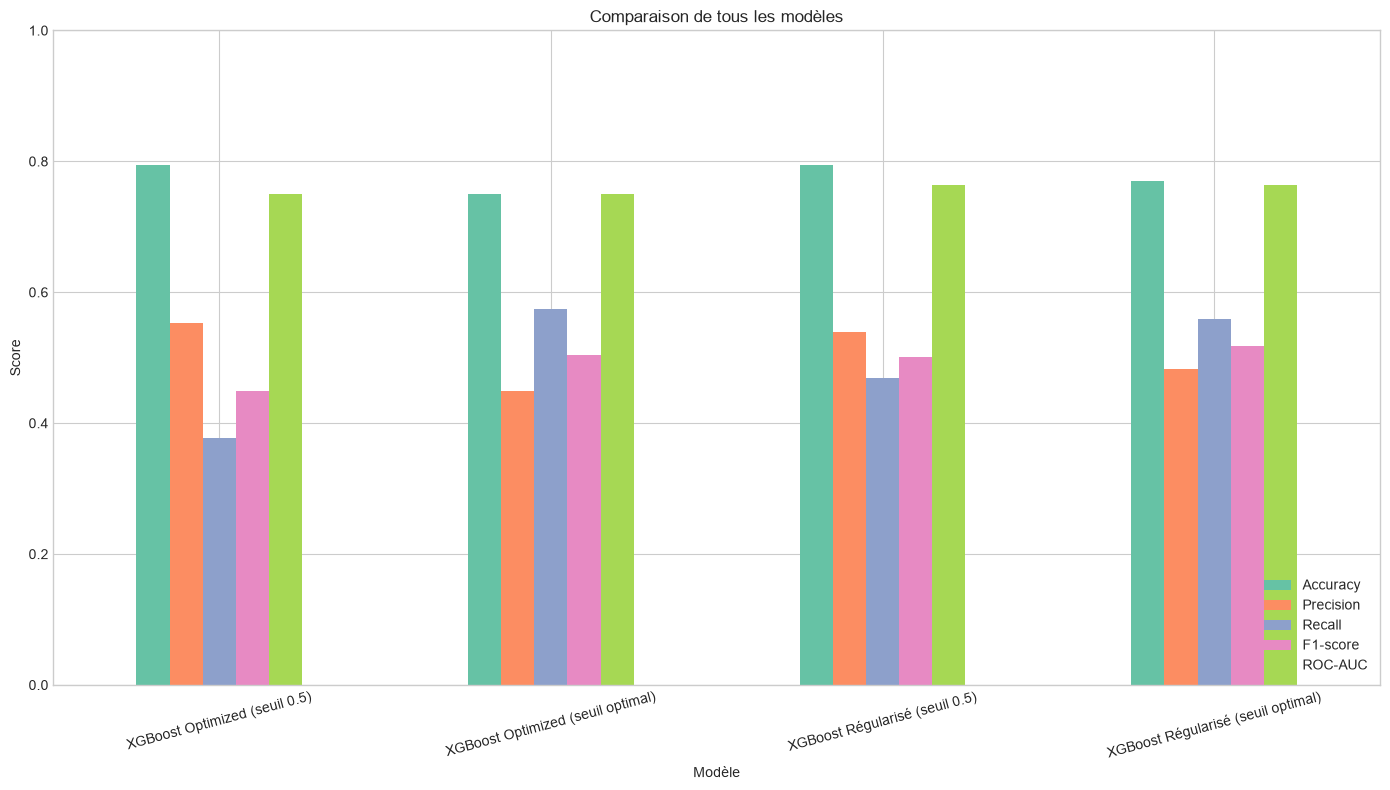


✅ Comparaison finale terminée !


In [2]:
# %% [markdown]
# ### 12. MODÈLE RÉGULARISÉ (Anti-Overfitting)

# %%
print("\n" + "="*60)
print("MODÈLE RÉGULARISÉ - ANTI-OVERFITTING")
print("="*60)

# Modèle avec régularisation
model_regularized = XGBClassifier(
    # Paramètres réduits pour éviter le surapprentissage
    n_estimators=150,
    max_depth=6,                # Réduit de 10 → 6
    learning_rate=0.05,         # Réduit de 0.1 → 0.05
    subsample=0.7,              # Réduit de 0.8 → 0.7
    colsample_bytree=0.8,       # Réduit de 1.0 → 0.8
    
    # Régularisation (NOUVEAU)
    reg_alpha=0.1,              # Régularisation L1
    reg_lambda=1.0,             # Régularisation L2
    gamma=0.1,                  # Réduction minimale de la perte
    
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Entraînement
model_regularized.fit(X_train_smote, y_train_smote)

# Prédictions
y_pred_reg = model_regularized.predict(X_test_scaled)
y_proba_reg = model_regularized.predict_proba(X_test_scaled)[:, 1]

print(f"\n=== PERFORMANCES MODÈLE RÉGULARISÉ ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_reg):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_reg):.4f}")

cm_reg = confusion_matrix(y_test, y_pred_reg)
print(f"\nMatrice de confusion:\n{cm_reg}")

# %% [markdown]
# ### 13. AJUSTEMENT DU SEUIL - MODÈLE RÉGULARISÉ

# %%
print("\n" + "="*60)
print("AJUSTEMENT DU SEUIL - MODÈLE RÉGULARISÉ")
print("="*60)

thresholds = np.arange(0.1, 0.6, 0.03)
threshold_results_reg = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_reg >= thresh).astype(int)
    threshold_results_reg.append({
        'Seuil': thresh,
        'Recall': recall_score(y_test, y_pred_thresh),
        'Precision': precision_score(y_test, y_pred_thresh),
        'F1': f1_score(y_test, y_pred_thresh)
    })

df_thresh_reg = pd.DataFrame(threshold_results_reg)

# Meilleur seuil
best_thresh_reg = df_thresh_reg.loc[df_thresh_reg['F1'].idxmax(), 'Seuil']
best_f1_reg = df_thresh_reg['F1'].max()

print(f"\n✅ Meilleur seuil: {best_thresh_reg:.2f}")
print(f"✅ Meilleur F1-score: {best_f1_reg:.4f}")

# %% [markdown]
# ### 14. MODÈLE RÉGULARISÉ - SEUIL OPTIMAL

# %%
y_pred_optimal_reg = (y_proba_reg >= best_thresh_reg).astype(int)

print("\n" + "="*60)
print("MODÈLE RÉGULARISÉ + SEUIL OPTIMAL")
print("="*60)
print(f"Seuil: {best_thresh_reg:.2f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_optimal_reg):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_optimal_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_reg):.4f}")

cm_reg_opt = confusion_matrix(y_test, y_pred_optimal_reg)
print(f"\nMatrice de confusion:\n{cm_reg_opt}")

# %% [markdown]
# ### 15. COMPARAISON FINALE - TOUS LES MODÈLES

# %%
print("\n" + "="*60)
print("COMPARAISON FINALE - TOUS LES MODÈLES")
print("="*60)

comparison_final = pd.DataFrame([
    {
        'Modèle': 'XGBoost Optimized (seuil 0.5)',
        'Accuracy': accuracy_score(y_test, best_xgb.predict(X_test_scaled)),
        'Precision': precision_score(y_test, best_xgb.predict(X_test_scaled)),
        'Recall': recall_score(y_test, best_xgb.predict(X_test_scaled)),
        'F1-score': f1_score(y_test, best_xgb.predict(X_test_scaled)),
        'ROC-AUC': roc_auc_score(y_test, best_xgb.predict_proba(X_test_scaled)[:, 1])
    },
    {
        'Modèle': 'XGBoost Optimized (seuil optimal)',
        'Accuracy': accuracy_score(y_test, y_pred_optimal),
        'Precision': precision_score(y_test, y_pred_optimal),
        'Recall': recall_score(y_test, y_pred_optimal),
        'F1-score': f1_score(y_test, y_pred_optimal),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    },
    {
        'Modèle': 'XGBoost Régularisé (seuil 0.5)',
        'Accuracy': accuracy_score(y_test, y_pred_reg),
        'Precision': precision_score(y_test, y_pred_reg),
        'Recall': recall_score(y_test, y_pred_reg),
        'F1-score': f1_score(y_test, y_pred_reg),
        'ROC-AUC': roc_auc_score(y_test, y_proba_reg)
    },
    {
        'Modèle': 'XGBoost Régularisé (seuil optimal)',
        'Accuracy': accuracy_score(y_test, y_pred_optimal_reg),
        'Precision': precision_score(y_test, y_pred_optimal_reg),
        'Recall': recall_score(y_test, y_pred_optimal_reg),
        'F1-score': f1_score(y_test, y_pred_optimal_reg),
        'ROC-AUC': roc_auc_score(y_test, y_proba_reg)
    }
])

print(comparison_final.round(4))

# Sauvegarde
comparison_final.to_csv('../data/processed/final_comparison_all_models.csv', index=False)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 8))
comparison_final.plot(kind='bar', x='Modèle', ax=ax)
ax.set_title('Comparaison de tous les modèles')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/final_all_models_comparison.png', dpi=150)
plt.show()

print("\n✅ Comparaison finale terminée !")

In [3]:
# %% [markdown]
# ### 16. SAUVEGARDE DU MODÈLE FINAL (RÉGULARISÉ)

# %%
# Sauvegarde du modèle régularisé (recommandé)
joblib.dump(model_regularized, '../models/xgboost_final_regularized.pkl')
joblib.dump(scaler, '../models/scaler_final.pkl')

with open('../models/best_threshold_regularized.txt', 'w') as f:
    f.write(str(best_thresh_reg))

print("\n✅ Modèle régularisé sauvegardé !")
print(f"   - Modèle: models/xgboost_final_regularized.pkl")
print(f"   - Seuil optimal: {best_thresh_reg:.2f}")


✅ Modèle régularisé sauvegardé !
   - Modèle: models/xgboost_final_regularized.pkl
   - Seuil optimal: 0.43


In [4]:
# Exemple d'utilisation dans l'API
import joblib
import numpy as np

# Chargement
model = joblib.load('models/xgboost_final_regularized.pkl')
scaler = joblib.load('models/scaler_final.pkl')
threshold = 0.43

# Prédiction
def predict(features):
    # features = liste de 35 valeurs
    features_scaled = scaler.transform([features])
    proba = model.predict_proba(features_scaled)[0, 1]
    default = 1 if proba >= threshold else 0
    return {
        'probability': proba,
        'default_predicted': default,
        'risk_score': int((1 - proba) * 100),
        'risk_category': 'HIGH' if proba >= 0.5 else 'MEDIUM' if proba >= 0.3 else 'LOW'
    }

FileNotFoundError: [Errno 2] No such file or directory: 'models/xgboost_final_regularized.pkl'